## CNN Model v5 With Metrics

*Patch Notes: v5.0 Updates*  
This version added the following implementations:
* Discard Horizontal and Vertical Flips in Data Augmentation
* Added new model evaluation metrics (precision, recall, f1, roc-auc)

### Google Drive & Extract Dataset
Connects to Google Drive and unzips the MRI dataset into local environment for Google Colab Training

In [2]:
from google.colab import drive

drive.mount('/content/drive')
!unzip -q "/content/drive/MyDrive/brain_mri_dataset.zip" -d "/content"

print('Exported dataset successfully...')

Exported dataset successfully...


### Data Preparation & Loading

This section handles the preprocessing pipeline and data loading for the Brain MRI dataset. The image processing includes:  
* Resizing all brain MRI scans to a $256 \times 256$ resolution and converting them into PyTorch tensors.
* Applying random rotations (up to 15 degrees) on the training set to improve generalization and prevent overfitting.
* Transforming images to one channel through Grayscaling
* Randomly altering image brightness/contrast
* Organizing images into `Training` and `Testing` sets using `ImageFolder` (mapping subdirectories to class labels).
* Creates data streams (`DataLoaders`) that shuffle the training data to prevent ordering bias and process images in batches of 32.

In [3]:
import torch
from torchvision import datasets, transforms

# load train and test dataset paths
train_path = 'brain_mri_dataset/Training/'
test_path = 'brain_mri_dataset/Testing/'

# transform for training images with data augmentation (ratio, flips, rotation, ratio)
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomRotation(degrees=15),  # randomly rotate by up to 15 degrees
    transforms.Grayscale(num_output_channels=1),  # converts to 1 channel
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # randomly slightly alter brightness/contrast
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # normalize image channels for convergence speed
])

# transform for testing images by converting to Tensors with 256x256 ratio
test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# load train/test datasets and subfolder names and pass respective transforms
train_dataset = datasets.ImageFolder(root=train_path, transform=train_transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=test_transform)

# image data loading in batches
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

print('Data Loaded Successfully...')

Data Loaded Successfully...


### Model Architecture

This section defines a custom CNN for classifying 4 distinct categories in the brain MRI dataset. The model includes:

Feature Extraction (convolutional layers each followed by batch normalization to stabilize training):
* Conv1: Accepts an RGB image (3 channels) and extracts 16 features. Max pooling halves the spatial resolution from $256 \times 256 \rightarrow 128 \times 128$.
* Conv2: Expands feature maps from 16 to 32. Max pooling halves the size from $128 \times 128 \rightarrow 64 \times 64$.
* Conv3: Expands feature maps from 32 to 64. Max pooling halves the final size from $64 \times 64 \rightarrow 32 \times 32$.
* Conv4: Expands feature maps from 64 to 128. Max pooling halves the final size from $32 \times 32 \rightarrow 16 \times 16$.  

Classification (fully connected layers):
  * Flatten Layer: Flattens the 3D feature maps into a 1D vector.
  * Linear 1: Maps features down to 512 dense representations with a ReLU activation function.
  * Dropout Layer: Randomly zeroes out neurons during training for regularization.
  * Linear 2: Outputs raw logits for the 4 target classification categories.

In [4]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # cut image size by half

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)  # input size: 256x256
        self.bn1 = nn.BatchNorm2d(num_features=16) # Match out_channels

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1) # input size: 128x128
        self.bn2 = nn.BatchNorm2d(num_features=32)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1) # input size: 64x64
        self.bn3 = nn.BatchNorm2d(num_features=64)

        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1) # input size: 32x32
        self.bn4 = nn.BatchNorm2d(num_features=128)

        self.dropout = nn.Dropout()
        self.full_conn1 = nn.Linear(in_features=128 * 16 * 16, out_features=512)  # input size: 16x16
        self.full_conn2 = nn.Linear(in_features=512, out_features=4)  # output size: 4 classes

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # output size: 128x128
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # output size: 64x64
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # output size: 32x32
        x = self.pool(F.relu(self.bn4(self.conv4(x))))  # output size: 16x16

        x = torch.flatten(x, start_dim=1)  # flatten the tensor for fully connected layer
        x = F.relu(self.full_conn1(x))
        x = self.dropout(x)
        x = self.full_conn2(x)
        return x

model = SimpleCNN()
print(model)

SimpleCNN(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (full_conn1): Linear(in_features=32768, out_features=512, bias=True)
  (full_conn2): Linear(in_features=512, out_features=4, bias=True)
)


### Model Training & Evaluation Loop

This section initializes the training configurations and executes the training loop over a set number of epochs.

Environment & Hyperparameters:
* Defaults to the CPU for computing.
* Loss Function uses `CrossEntropyLoss`, which is good for multi-class classification problems.
* Implements the **Adam** optimizer with a learning rate of `0.0005` and a weight decay of `1e-5` for L2 regularization to control overfitting.
* Set an Adaptive Learning Rate Scheduler to automatically halve the learning rate if the accuracy decreases after 2 epochs
* Epochs are set to run for `25` passes through the entire dataset.
* Initializes tracking arrays (`train_losses`, `train_accuracies`, `test_accuracies`) to record running progress across epochs.
* Initializes lists to track the history of performance through various metrics

Training Pipeline (per run):
* Training Phase --> `model.train()`
* Evaluation Phase --> `model.eval()`

In [5]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# move the model to the chosen device (cpu)
model = model.to(device)

# define loss function (criterion), optimizer, and adaptive lr scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

# set num of epochs (passes through the dataset)
epochs = 25

# init lists to track history of stats
train_losses = []
train_accuracies = []
test_accuracies = []

# init lists to track history of performance thru various metrics
test_precisions = []
test_recalls = []
test_f1_scores = []
test_roc_aucs = []

for epoch in range(epochs):
    # ------ TRAINING PHASE ------
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        # move data to the same device as model
        images, labels = images.to(device), labels.to(device)

        # reset/zero out the parameter gradients
        optimizer.zero_grad()

        # forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # backward pass and optimize
        loss.backward()
        optimizer.step()

        # track training stats (error and accuracy)
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)  # _ represents the max logit value; we only care about predicted index value of logit
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # track total training stats per epoch
    epoch_loss = running_loss / total_train
    epoch_acc = (correct_train / total_train) * 100

    # -------- TESTING PHASE --------
    model.eval()
    correct_test = 0
    total_test = 0

    # init temp lists to collect all true labels, predictions, and probabilities per epoch
    all_true_labels = []
    all_pred_labels = []
    all_pred_probs = []

    with torch.no_grad(): # disable gradient calculation for efficiency, since no longer needed because not in training phase
        # forward pass
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            # track testing stats (accuracy)
            _, predicted = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

            # save true labels and predicted labels for scikit-learn evaluation
            all_true_labels.extend(labels.cpu().numpy())
            all_pred_labels.extend(predicted.cpu().numpy())

            # calc class probabilities using softmax
            probabilities = F.softmax(outputs, dim=1)
            all_pred_probs.extend(probabilities.cpu().numpy())

    # track total testing accuracy per epoch
    test_acc = (correct_test / total_test) * 100

    # using weighted average to account for any class imbalance
    epoch_precision = precision_score(all_true_labels, all_pred_labels, average='weighted', zero_division=0)
    epoch_recall = recall_score(all_true_labels, all_pred_labels, average='weighted', zero_division=0)
    epoch_f1 = f1_score(all_true_labels, all_pred_labels, average='weighted', zero_division=0)

    # using ovr (one vs rest) strategy to calc multi class ROC-AUC score
    epoch_roc_auc = roc_auc_score(all_true_labels, all_pred_probs, multi_class='ovr', average='weighted')

    # step scheduler based on test accuracy
    scheduler.step(test_acc)

    # save epoch stats to history lists
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    test_accuracies.append(test_acc)

    # save metrics to history lists
    test_precisions.append(epoch_precision)
    test_recalls.append(epoch_recall)
    test_f1_scores.append(epoch_f1)
    test_roc_aucs.append(epoch_roc_auc)

    # print stats for each epoch, kept to 4 decimal places
    print(f"Epoch {epoch+1}/{epochs} "
          f"| Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}% "
          f"| Test Acc: {test_acc:.4f}% | Test Precision: {epoch_precision:.4f} "
          f"| Test Recall: {epoch_recall:.4f} | Test F1: {epoch_f1:.4f} | Test AUC: {epoch_roc_auc:.4f}")

print("Training finished!")

Using device: cpu
Epoch 1/25 | Train Loss: 1.0892 | Train Acc: 68.2679% | Test Acc: 75.5625% | Test Precision: 0.7726 | Test Recall: 0.7556 | Test F1: 0.7516 | Test AUC: 0.9123
Epoch 2/25 | Train Loss: 0.5650 | Train Acc: 78.1964% | Test Acc: 74.7500% | Test Precision: 0.7489 | Test Recall: 0.7475 | Test F1: 0.7358 | Test AUC: 0.9110
Epoch 3/25 | Train Loss: 0.4826 | Train Acc: 81.5536% | Test Acc: 80.8750% | Test Precision: 0.8104 | Test Recall: 0.8087 | Test F1: 0.8023 | Test AUC: 0.9391
Epoch 4/25 | Train Loss: 0.3870 | Train Acc: 85.0536% | Test Acc: 82.1250% | Test Precision: 0.8343 | Test Recall: 0.8213 | Test F1: 0.8168 | Test AUC: 0.9428
Epoch 5/25 | Train Loss: 0.3548 | Train Acc: 87.2679% | Test Acc: 82.0000% | Test Precision: 0.8265 | Test Recall: 0.8200 | Test F1: 0.8152 | Test AUC: 0.9479
Epoch 6/25 | Train Loss: 0.3317 | Train Acc: 87.2857% | Test Acc: 81.0000% | Test Precision: 0.8408 | Test Recall: 0.8100 | Test F1: 0.8031 | Test AUC: 0.9507
Epoch 7/25 | Train Loss: 0.3

### Classification Metric Report
Generates a summary report for individual classes

In [6]:
class_names = test_dataset.classes
print("Classification Metric Report:\n")
print(classification_report(all_true_labels, all_pred_labels, target_names=class_names, digits=4))

Classification Metric Report:

              precision    recall  f1-score   support

      glioma     0.9349    0.7900    0.8564       400
  meningioma     0.8595    0.9175    0.8875       400
     notumor     0.9294    0.9875    0.9576       400
   pituitary     0.9585    0.9825    0.9704       400

    accuracy                         0.9194      1600
   macro avg     0.9206    0.9194    0.9180      1600
weighted avg     0.9206    0.9194    0.9180      1600



### Metric Visualizations

This section plots the training loss and accuracy progress over all epochs. The graphs include:  

* Tracking how well the model is minimizing its error.
* Comparing the training accuracy and testing accuracy.
* All new metrics in separate graphs.

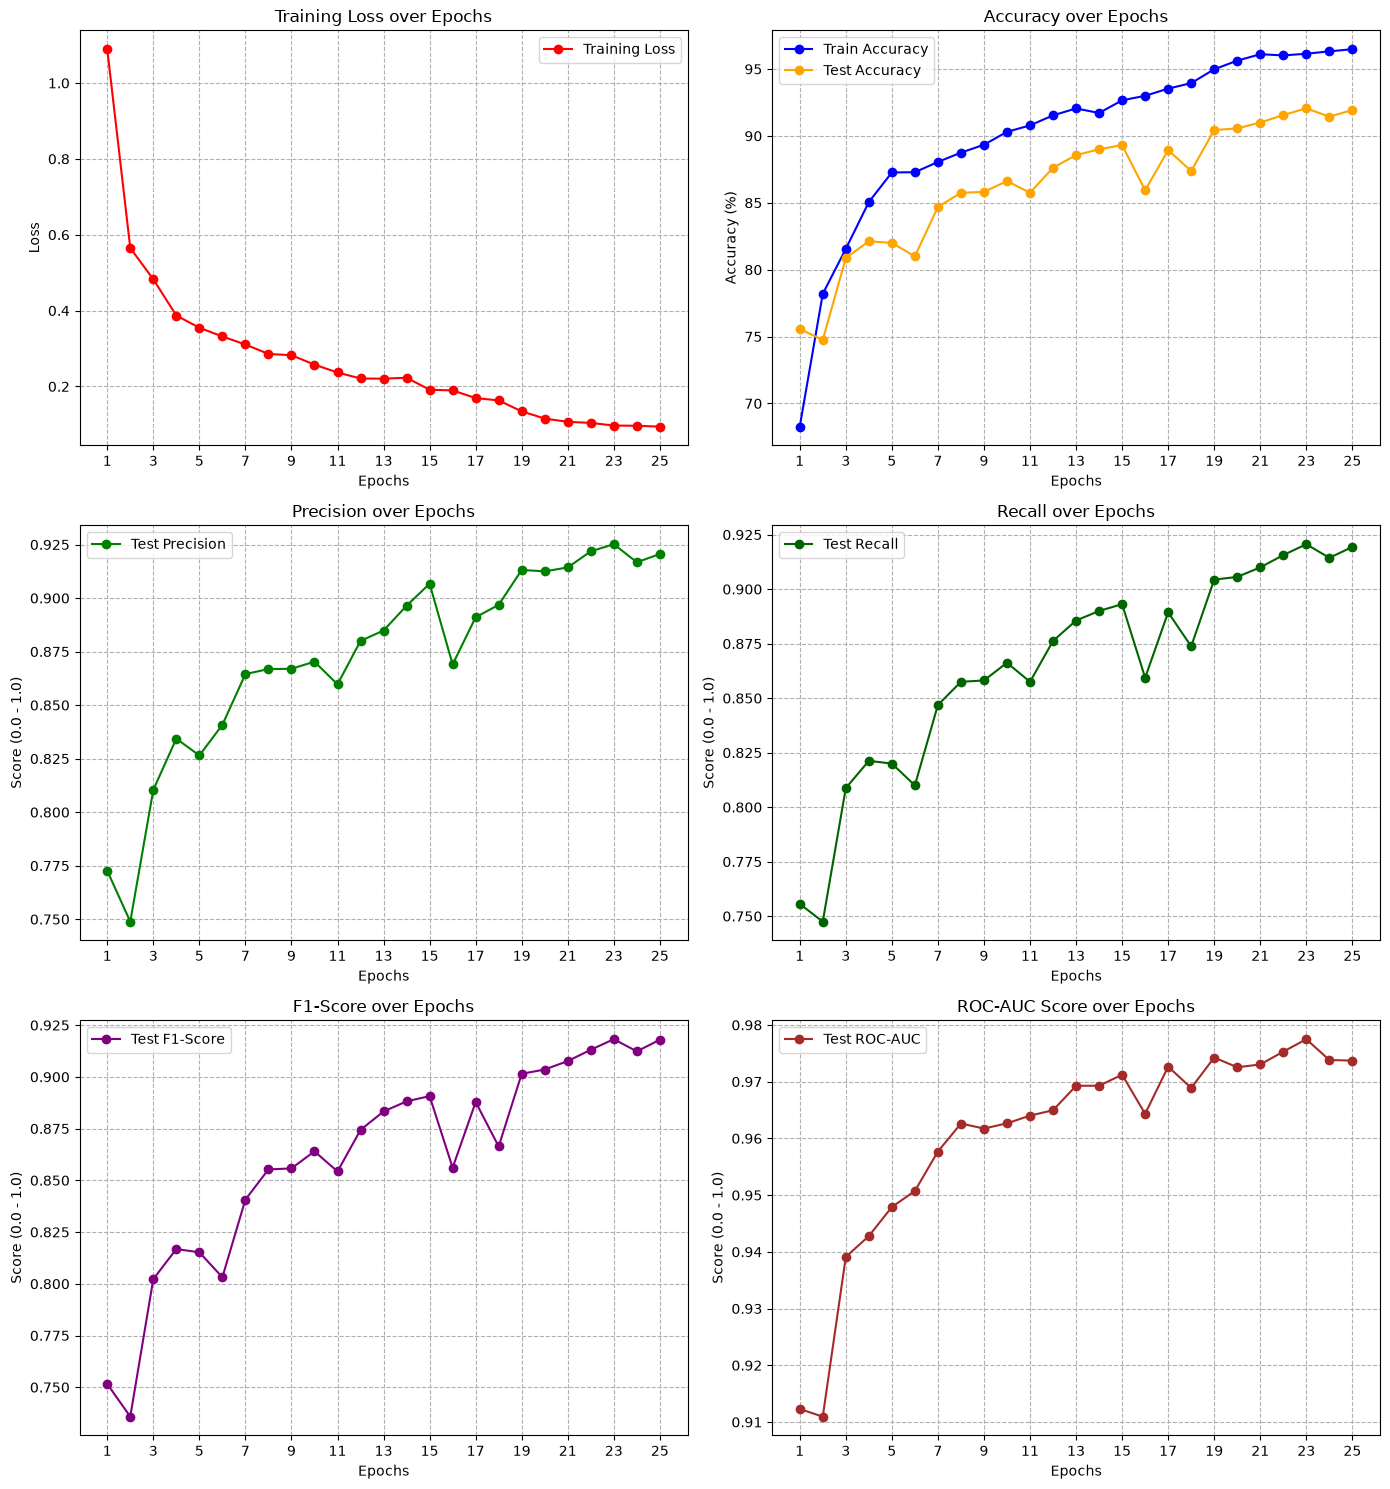

In [7]:
import matplotlib.pyplot as plt
epochs_range = range(1, epochs + 1)

# create 1x2 grid layout for standard metrics (loss & accuracy)
fig, ((plot1, plot2), (plot3, plot4), (plot5, plot6)) = plt.subplots(3, 2, figsize=(14, 15))

# plot 1: training Loss
plot1.plot(epochs_range, train_losses, label='Training Loss', color='red', marker='o')
plot1.set_title('Training Loss over Epochs')
plot1.set_xlabel('Epochs')
plot1.set_ylabel('Loss')
plot1.set_xticks(epochs_range[::2])  # integer steps on the x axis
plot1.grid(True, linestyle='--')
plot1.legend()

# plot 2: training and testing accuracy
plot2.plot(epochs_range, train_accuracies, label='Train Accuracy', color='blue', marker='o')
plot2.plot(epochs_range, test_accuracies, label='Test Accuracy', color='orange', marker='o')
plot2.set_title('Accuracy over Epochs')
plot2.set_xlabel('Epochs')
plot2.set_ylabel('Accuracy (%)')
plot2.set_xticks(epochs_range[::2])
plot2.grid(True, linestyle='--')
plot2.legend()

# plot 3: precision score
plot3.plot(epochs_range, test_precisions, label='Test Precision', color='green', marker='o')
plot3.set_title('Precision over Epochs')
plot3.set_xlabel('Epochs')
plot3.set_ylabel('Score (0.0 - 1.0)')
plot3.set_xticks(epochs_range[::2])
plot3.grid(True, linestyle='--')
plot3.legend()

# plot 4: recall score
plot4.plot(epochs_range, test_recalls, label='Test Recall', color='darkgreen', marker='o')
plot4.set_title('Recall over Epochs')
plot4.set_xlabel('Epochs')
plot4.set_ylabel('Score (0.0 - 1.0)')
plot4.set_xticks(epochs_range[::2])
plot4.grid(True, linestyle='--')
plot4.legend()

# Plot 5: f1 score
plot5.plot(epochs_range, test_f1_scores, label='Test F1-Score', color='purple', marker='o')
plot5.set_title('F1-Score over Epochs')
plot5.set_xlabel('Epochs')
plot5.set_ylabel('Score (0.0 - 1.0)')
plot5.set_xticks(epochs_range[::2])
plot5.grid(True, linestyle='--')
plot5.legend()

# Plot 6: roc auc score
plot6.plot(epochs_range, test_roc_aucs, label='Test ROC-AUC', color='brown', marker='o')
plot6.set_title('ROC-AUC Score over Epochs')
plot6.set_xlabel('Epochs')
plot6.set_ylabel('Score (0.0 - 1.0)')
plot6.set_xticks(epochs_range[::2])
plot6.grid(True, linestyle='--')
plot6.legend()

plt.tight_layout()
plt.show()

#### Saving the model

In [8]:
PATH = 'brain_mri_cnn_v5.pth'

torch.save(model.state_dict(), PATH)
print(f"Model weights saved successfully to {PATH}")

Model weights saved successfully to brain_mri_cnn_v5.pth


#### Copy code to load the model later  
```import torch

model = SimpleCNN()
PATH = "brain_mri_simple_cnn.pth"
model.load_state_dict(torch.load(PATH))

model.eval()
print("Model loaded and ready for inference!")
